In [91]:
from pytorch_model import (
    SmallCNN,
    get_dataloaders,
    train_model,
    evaluate_model,
    visualize_predictions,
    save_model
)
from torchinfo import summary
import torch
from flax import nnx
import jax.numpy as jnp
from jax import random
import jax

In [42]:

# Get the data (it will download automatically the first time)
print("Loading data...")
train_loader, test_loader, class_names = get_dataloaders(batch_size=64)

Loading data...


In [43]:
# Initialize the model
model = SmallCNN()

In [44]:
# Train the model (just one function call!)
print("Starting training...")
train_model(model, train_loader, num_epochs=5, lr=0.001)

Starting training...
Training on device: cpu

Epoch [1/5], Average Loss: 0.4433
Epoch [2/5], Average Loss: 0.2787
Epoch [3/5], Average Loss: 0.2335
Epoch [4/5], Average Loss: 0.2008
Epoch [5/5], Average Loss: 0.1758


Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [45]:
# Evaluate the model
evaluate_model(model, test_loader)


Accuracy on the test set: 91.35%


91.35

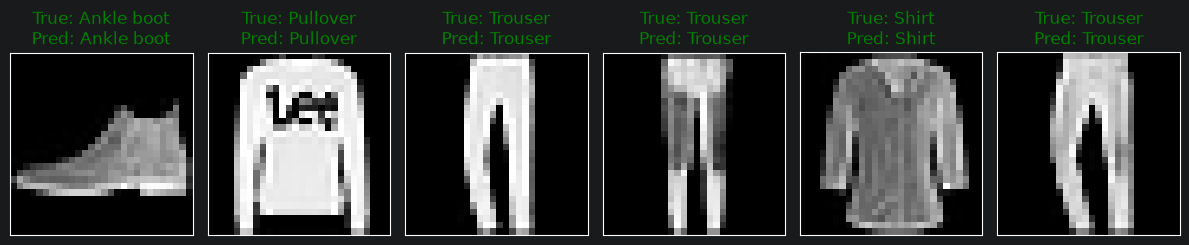

In [46]:
# Visualize some predictions
visualize_predictions(model, test_loader, class_names, num_images=6)

In [47]:
# 6. Save it for later use
save_model(model, "cnn_torch.pth")

Model saved to 'cnn_torch.pth'


In [48]:
# Print the model summary
summary(model, input_size=(64, 1, 28, 28), col_names=["input_size", "output_size", "num_params", "kernel_size"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
SmallCNN                                 [64, 1, 28, 28]           [64, 10]                  --                        --
├─Conv2d: 1-1                            [64, 1, 28, 28]           [64, 32, 28, 28]          320                       [3, 3]
├─MaxPool2d: 1-2                         [64, 32, 28, 28]          [64, 32, 14, 14]          --                        2
├─Conv2d: 1-3                            [64, 32, 14, 14]          [64, 64, 14, 14]          18,496                    [3, 3]
├─MaxPool2d: 1-4                         [64, 64, 14, 14]          [64, 64, 7, 7]            --                        2
├─Linear: 1-5                            [64, 3136]                [64, 128]                 401,536                   --
├─Linear: 1-6                            [64, 128]                 [64, 10]                  1,290                     --
Total pa

In [49]:
# Load the model state dictionary
model_file = "cnn_torch.pth"
with open(model_file, "rb") as state_f:
    pt_state = torch.load(state_f)
    pt_state = {k: v.numpy() for k, v in pt_state.items()}

In [50]:
# Keys of the state dictionary
print("Keys of the state dictionary:")
for key in pt_state.keys():
    print(key)

Keys of the state dictionary:
conv1.weight
conv1.bias
conv2.weight
conv2.bias
fc1.weight
fc1.bias
fc2.weight
fc2.bias


In [161]:
class CNN(nnx.Module):
    def __init__(self, rngs):
        # 1. Removed 'self' from the arguments
        # 2. Added correct in_features to the Linear layers
        self.conv1 = nnx.Conv(1, 32, (3, 3), padding='SAME', rngs=rngs)
        self.conv2 = nnx.Conv(32, 64, (3, 3), padding='SAME', rngs=rngs)

        # Note: 64 channels * 8 height * 8 width = 4096 (Adjust 8*8 if your input image is a different size, e.g., 7*7 for 28x28 MNIST images)
        self.fc1 = nnx.Linear(3136, 128, rngs=rngs)
        self.fc2 = nnx.Linear(128, 10, rngs=rngs)

    def __call__(self, x):
        x = nnx.relu(self.conv1(x))
        x = nnx.max_pool(x, (2, 2), (2, 2))
        x = nnx.relu(self.conv2(x))
        x = nnx.max_pool(x, (2, 2), (2, 2))
        x = x.reshape((x.shape[0], -1))
        x = nnx.relu(self.fc1(x))
        x = self.fc2(x)
        return x



In [162]:
# Initialize the Flax model
flax_model = CNN(rngs=nnx.Rngs(0))

y = flax_model(jnp.ones((1, 28, 28, 1)))
y

Array([[-0.5847423 ,  0.5149929 ,  0.83419186, -0.06421899, -0.4978068 ,
        -0.09015329,  0.32474098, -0.06136806, -0.27608308, -0.40179718]],      dtype=float32)

In [163]:
flax_model

CNN( # Param: 421,642 (1.7 MB)
  conv1=Conv( # Param: 320 (1.3 KB)
    kernel_shape=(3, 3, 1, 32),
    kernel=Param( # 288 (1.2 KB)
      value=Array(shape=(3, 3, 1, 32), dtype=dtype('float32'))
    ),
    bias=Param( # 32 (128 B)
      value=Array(shape=(32,), dtype=dtype('float32'))
    ),
    in_features=1,
    out_features=32,
    kernel_size=(3, 3),
    strides=1,
    padding='SAME',
    input_dilation=1,
    kernel_dilation=1,
    feature_group_count=1,
    use_bias=True,
    mask=None,
    dtype=None,
    param_dtype=float32,
    precision=None,
    conv_general_dilated=<function conv_general_dilated at 0x116111620>,
    promote_dtype=<function promote_dtype at 0x116b12980>,
    preferred_element_type=None
  ),
  conv2=Conv( # Param: 18,496 (74.0 KB)
    kernel_shape=(3, 3, 32, 64),
    kernel=Param( # 18,432 (73.7 KB)
      value=Array(shape=(3, 3, 32, 64), dtype=dtype('float32'))
    ),
    bias=Param( # 64 (256 B)
      value=Array(shape=(64,), dtype=dtype('float32'))
    ),


In [164]:
flax_state = nnx.state(flax_model)
for key, value in flax_state.items():
    print(f"{key}: {value}")

conv1: State({
  'bias': Param( # 32 (128 B)
    value=Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float32)
  ),
  'kernel': Param( # 288 (1.2 KB)
    value=Array([[[[ 0.35672593, -0.32324237, -0.2681508 , -0.41283748,
              -0.3111    ,  0.21182604,  0.25962782, -0.3640587 ,
               0.5625262 , -0.62065995, -0.45105332,  0.04831367,
              -0.40678248,  0.08648089,  0.58471596,  0.18194778,
               0.21403538, -0.17044018,  0.3264501 ,  0.1303914 ,
              -0.22791803, -0.31084284,  0.27173665,  0.37665302,
               0.3239391 , -0.17740908,  0.31707639,  0.5580605 ,
              -0.72174084,  0.1593173 ,  0.60305494, -0.41342163]],
    
            [[-0.21178283,  0.6727487 ,  0.2869636 , -0.07137904,
              -0.5834153 , -0.2937824 , -0.70502573,  0.53178334,
               0.48768008,  0.12649909,  0.02259199,  0.40479472,


In [165]:
def flatten_state_dict(state, parent_key=''):
    flat_dict = {}
    for k, v in state.items():
        new_key = f"{parent_key}/{k}" if parent_key else k

        if hasattr(v, 'items'):
            flat_dict.update(flatten_state_dict(v, new_key))
        # Utiliser v[...] au lieu de v.value
        elif hasattr(v, 'get_value'):
            flat_dict[new_key] = v[...]
    return flat_dict

flax_state = nnx.state(flax_model)
flat_flax_dict = flatten_state_dict(flax_state)

for key, value in flat_flax_dict.items():
    print(f"{key}: {value.shape}")

conv1/bias: (32,)
conv1/kernel: (3, 3, 1, 32)
conv2/bias: (64,)
conv2/kernel: (3, 3, 32, 64)
fc1/bias: (128,)
fc1/kernel: (3136, 128)
fc2/bias: (10,)
fc2/kernel: (128, 10)


In [166]:
# Keys of the state dictionary
print("Keys of the state dictionary:")
for key in pt_state.keys():
    print(key)

Keys of the state dictionary:
conv1.weight
conv1.bias
conv2.weight
conv2.bias
fc1.weight
fc1.bias
fc2.weight
fc2.bias


In [167]:
pt_state['conv1.weight']

array([[[[-0.14619434, -0.12697758,  0.16923359],
         [-0.3977731 , -0.49560127,  0.31489244],
         [ 0.08919995, -0.04041119,  0.31046078]]],


       [[[ 0.04922045,  0.13577826, -0.15094574],
         [-0.4026337 ,  0.31967604,  0.10514106],
         [-0.36441457,  0.52230996, -0.19548512]]],


       [[[ 0.03892997,  0.3023521 ,  0.10345416],
         [ 0.3077043 ,  0.24090044,  0.265752  ],
         [ 0.08075602,  0.04640863, -0.21679291]]],


       [[[-0.08635753, -0.4037308 ,  0.41982144],
         [-0.12841581,  0.306077  ,  0.00150958],
         [ 0.25542486,  0.17319395,  0.13590588]]],


       [[[ 0.32614622,  0.18601586,  0.35669747],
         [-0.12021141, -0.29332295,  0.01186882],
         [-0.40520838, -0.4021551 , -0.27138078]]],


       [[[-0.1342965 ,  0.3735288 , -0.39788115],
         [ 0.06390597,  0.38039827, -0.48552623],
         [ 0.00127224,  0.24341603, -0.0404923 ]]],


       [[[ 0.23646462, -0.0006219 , -0.13109872],
         [ 0.32371974, -0.

In [168]:
# Conv1
variables = {'params': {'kernel': pt_state['conv1.weight'], 'bias': pt_state['conv1.bias']}}
flax_model.conv1 = flax_model.conv1.apply(variables)


AttributeError: 'Conv' object has no attribute 'apply'

In [169]:
conv1_kernel = pt_state['conv1.weight'].transpose(2, 3, 1, 0)  # PyTorch: (out_channels, in_channels, H, W) -> Flax: (H, W, in_channels, out_channels)
conv1_bias = pt_state['conv1.bias']
conv2_kernel = pt_state['conv2.weight'].transpose(2, 3, 1, 0)
conv2_bias = pt_state['conv2.bias']
fc1_weight = pt_state['fc1.weight'].T  # PyTorch: (out_features, in_features) -> Flax: (in_features, out_features)
fc1_bias = pt_state['fc1.bias']
fc2_weight = pt_state['fc2.weight'].T
fc2_bias = pt_state['fc2.bias']

In [170]:
variables = {
    'params': {
        'conv1': {'kernel': conv1_kernel, 'bias': conv1_bias},
        'conv2': {'kernel': conv2_kernel, 'bias': conv2_bias},
        'fc1': {'kernel': fc1_weight, 'bias': fc1_bias},
        'fc2': {'kernel': fc2_weight, 'bias': fc2_bias}
    }
}

In [171]:
flax_model = CNN(rngs=nnx.Rngs(0))

In [172]:
key = random.key(0)
x = random.normal(key, (1, 28, 28, 1))

In [173]:
flax_model_out = flax_model.apply(variables, x)

AttributeError: 'CNN' object has no attribute 'apply'

In [174]:
class Identity(nnx.Module):
    def __call__(self, x: jax.Array) -> jax.Array:
        return x

In [175]:
import torch.nn as nn
import math


def _conv_params_permute(name, torch_param):
    if name == "weight":
        return torch_param.permute(2, 3, 1, 0).contiguous()
    return torch_param

def _linear_params_permute(name, torch_param):
    if name == "weight":
        return torch_param.permute(1, 0).contiguous()
    return torch_param

def _default_params_transform(name, param):
    return param


class Torch2Flax:
    def __init__(self):
        self._last_conv_out_channels = None

    modules_mapping_info = {
                                   nn.Conv2d: {
                                           "type": nnx.Conv,
                                           "params_mapping": {
                                                   "weight": "kernel",
                                                   "bias": "bias",
                                           },
                                           "params_transform": _conv_params_permute,
                                   },
                                   nn.Linear: {
                                           "type": nnx.Linear,
                                           "params_mapping": {
                                                   "weight": "kernel",
                                                   "bias": "bias",
                                           },
                                           "params_transform": _linear_params_permute,
                                   },

                           } | {
                                   torch_mod: {
                                           "type": nnx_fn_type,
                                           "params_mapping": {},
                                   } for torch_mod, nnx_fn_type in [
                    (nn.Identity, Identity),
                    (nn.Flatten, type(lambda x: x)),
                    (nn.ReLU, type(nnx.relu)),
                    (nn.GELU, type(nnx.gelu)),
                    (nn.SELU, type(nnx.selu)),
                    (nn.SiLU, type(nnx.silu)),
                    (nn.Tanh, type(nnx.tanh)),
                    (nn.Dropout, nnx.Dropout),
                    (nn.Sigmoid, type(nnx.sigmoid)),
                    (nn.AvgPool2d, type(lambda x: nnx.avg_pool(x, (2, 2)))),
                    (nn.AdaptiveAvgPool2d, type(lambda x: nnx.avg_pool(x, (x.shape[1], x.shape[2])))),
            ]
                           }

    def _copy_params_buffers(self, torch_nn_module, nnx_module):
        torch_module_type = type(torch_nn_module)
        assert torch_module_type in self.modules_mapping_info, torch_module_type
        module_mapping_info = self.modules_mapping_info[torch_module_type]
        assert isinstance(nnx_module, module_mapping_info["type"]), (
                nnx_module, type(nnx_module), module_mapping_info["type"]
        )

        for torch_key, nnx_key in module_mapping_info["params_mapping"].items():

            torch_value = getattr(torch_nn_module, torch_key)
            nnx_param = getattr(nnx_module, nnx_key)
            assert nnx_param is not None, (torch_key, nnx_key, nnx_module)

            if torch_value is None:
                assert nnx_param.get_value() is None, nnx_param
                continue

            params_transform = module_mapping_info.get("params_transform", _default_params_transform)
            torch_value = params_transform(torch_key, torch_value)

            # Post-process: for Linear weight following conv+pool layers,
            # permute rows from channel-major to spatial-major order
            # to match NHWC flatten ordering.
            if (isinstance(torch_nn_module, nn.Linear)
                    and torch_key == "weight"
                    and self._last_conv_out_channels is not None):
                C = self._last_conv_out_channels
                in_features = torch_nn_module.in_features
                if in_features > C and in_features % C == 0:
                    remaining = in_features // C
                    H = int(math.isqrt(remaining))
                    W = H
                    if H * W == remaining:
                        perm = torch.empty(in_features, dtype=torch.long)
                        for c_idx in range(C):
                            for h_idx in range(H):
                                for w_idx in range(W):
                                    cm_idx = c_idx * H * W + h_idx * W + w_idx
                                    sm_idx = (h_idx * W + w_idx) * C + c_idx
                                    perm[sm_idx] = cm_idx
                        torch_value = torch_value[perm]

            nnx_val = nnx_param.get_value()
            assert nnx_val.shape == torch_value.data.shape, (
                    nnx_key, nnx_val.shape, torch_key, torch_value.data.shape
            )
            nnx_param.set_value(jnp.asarray(torch_value.data))

    def _copy_sequential(self, torch_nn_seq, nnx_seq, skip_modules=None):
        assert isinstance(torch_nn_seq, (nn.Sequential, nn.ModuleList)), type(torch_nn_seq)
        assert isinstance(nnx_seq, nnx.Sequential), type(nnx_seq)
        for i in range(len(torch_nn_seq)):
            torch_module = torch_nn_seq[i]
            nnx_module = nnx_seq.layers[i]
            self.copy_module(torch_module, nnx_module, skip_modules=skip_modules)

    def copy_module(self, torch_module, nnx_module, skip_modules=None):
        if skip_modules is None:
            skip_modules = []

        if isinstance(torch_module, (nn.Sequential, nn.ModuleList)):
            self._copy_sequential(torch_module, nnx_module, skip_modules=skip_modules)
        elif type(torch_module) in self.modules_mapping_info:
            if isinstance(torch_module, nn.Conv2d):
                self._last_conv_out_channels = torch_module.out_channels
            self._copy_params_buffers(torch_module, nnx_module)
        else:
            if skip_modules is not None:
                if torch_module.__class__.__name__ in skip_modules:
                    return

            named_children = list(torch_module.named_children())
            assert len(named_children) > 0, type(torch_module)
            for name, torch_child in named_children:
                nnx_child = getattr(nnx_module, name, None)

                if nnx_child is None:
                    has_params = bool(list(torch_child.parameters()))
                    has_buffers = bool(list(torch_child.buffers()))
                    if not has_params and not has_buffers:
                        continue
                    else:
                        raise AttributeError(
                                f"Missing submodule '{name}' in Flax model which contains parameters."
                        )

                self.copy_module(torch_child, nnx_child, skip_modules=skip_modules)

            for name, torch_buffer in torch_module.named_buffers():
                if "." in name:
                    continue
                nnx_buffer = getattr(nnx_module, name)
                assert isinstance(nnx_buffer, nnx.Variable), (name, nnx_buffer, nnx_module)

                nnx_buf_val = nnx_buffer.get_value()
                assert nnx_buf_val.shape == torch_buffer.shape, (
                        name, nnx_buf_val.shape, torch_buffer.shape
                )
                nnx_buffer.set_value(jnp.asarray(torch_buffer))

            for name, torch_param in torch_module.named_parameters():
                if "." in name:
                    continue
                nnx_param = getattr(nnx_module, name)
                assert isinstance(nnx_param, nnx.Param), (name, nnx_param, nnx_module)

                nnx_p_val = nnx_param.get_value()
                assert nnx_p_val.shape == torch_param.data.shape, (
                        name, nnx_p_val.shape, torch_param.data.shape
                )
                nnx_param.set_value(jnp.asarray(torch_param.data))


def test_modules(
        nnx_module, torch_module, torch_input, atol=1e-3, mode="eval", permute_torch_input=True, device="cuda"
):
    assert torch_input.ndim == 4
    assert mode in ("eval", "train")

    torch_input = torch_input.to(device)
    torch_module = torch_module.to(device)

    if mode == "eval":
        torch_module.eval()
        nnx_module.eval()
    else:
        torch_module.train()
        nnx_module.train()

    with torch.inference_mode(mode=mode=="eval"):
        torch_output = torch_module(torch_input)

    if permute_torch_input:
        torch_input = torch_input.permute(0, 2, 3, 1).contiguous()

    jax_input = jnp.asarray(torch_input, device=jax.devices(device)[0])
    jax_output = nnx_module(jax_input)
    assert jax_output.device == jax.devices(device)[0]

    torch_output = torch_output.detach()
    if permute_torch_input and torch_output.ndim == 4:
        torch_output = torch_output.permute(0, 2, 3, 1).contiguous()
    jax_expected = jnp.asarray(torch_output)

    assert jnp.allclose(jax_output, jax_expected, atol=atol), (
            jnp.abs(jax_output - jax_expected).max(),
            jnp.abs(jax_output - jax_expected).mean(),
    )



t2f = Torch2Flax()


In [176]:
t2f.copy_module(model, flax_model)

In [177]:
test_modules(flax_model, model, torch.randn(1, 1, 28, 28), device="cpu")



In [178]:
# Eval flax model
flax_model

CNN( # Param: 421,642 (1.7 MB)
  conv1=Conv( # Param: 320 (1.3 KB)
    kernel_shape=(3, 3, 1, 32),
    kernel=Param( # 288 (1.2 KB)
      value=Array(shape=(3, 3, 1, 32), dtype=dtype('float32'))
    ),
    bias=Param( # 32 (128 B)
      value=Array(shape=(32,), dtype=dtype('float32'))
    ),
    in_features=1,
    out_features=32,
    kernel_size=(3, 3),
    strides=1,
    padding='SAME',
    input_dilation=1,
    kernel_dilation=1,
    feature_group_count=1,
    use_bias=True,
    mask=None,
    dtype=None,
    param_dtype=float32,
    precision=None,
    conv_general_dilated=<function conv_general_dilated at 0x116111620>,
    promote_dtype=<function promote_dtype at 0x116b12980>,
    preferred_element_type=None
  ),
  conv2=Conv( # Param: 18,496 (74.0 KB)
    kernel_shape=(3, 3, 32, 64),
    kernel=Param( # 18,432 (73.7 KB)
      value=Array(shape=(3, 3, 32, 64), dtype=dtype('float32'))
    ),
    bias=Param( # 64 (256 B)
      value=Array(shape=(64,), dtype=dtype('float32'))
    ),


In [179]:
total_correct = 0
total_samples = 0

for images, labels in test_loader:
    # 1. Convert images to numpy, then transpose for JAX (NHWC)
    images = images.numpy().transpose(0, 2, 3, 1)

    # 2. Convert PyTorch labels to JAX array to match predictions
    labels = jnp.array(labels)

    outputs = flax_model(jnp.array(images))
    predictions = jnp.argmax(outputs, axis=1)

    # 3. Use .item() to extract standard Python int from the JAX sum
    total_correct += jnp.sum(predictions == labels).item()

    # 4. FIX: Use len() to get the batch size
    total_samples += len(labels)

accuracy = total_correct / total_samples
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9135
